In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from scipy.stats import norm

In [2]:
def black_scholes(S, K, T=2, r=0.05, sigma=0.1, option_type='call'):
    """
    Calculates the theoretical price of a European option.
    
    Parameters:
    S : float : Current stock price
    K : float : Strike price
    T : float : Time to maturity (in years)
    r : float : Risk-free interest rate (annualized)
    sigma : float : Volatility of the underlying asset (annualized)
    option_type : str : 'call' or 'put'
    """
    # Handle the boundary condition at expiration
    if T <= 0:
        if option_type == 'call':
            return max(0.0, S - K)
        elif option_type == 'put':
            return max(0.0, K - S)
        else:
            raise ValueError("Invalid option_type. Use 'call' or 'put'.")

    # Calculate d1 and d2
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Calculate the option price
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("Invalid option_type. Use 'call' or 'put'.")
    hedge_weight=norm.cdf(d1)-1
    return price,hedge_weight

In [3]:
def simulate_gbm(S0, mu, sigma, T, N, num_paths=10):
    """
    Simulates paths for a single asset following Geometric Brownian Motion.
    
    Parameters:
    - S0: Initial stock price
    - mu: Expected annual return (drift)
    - sigma: Annual volatility
    - T: Time horizon in years
    - N: Number of discrete time steps
    - num_paths: Number of simulated trajectories
    
    Returns:
    - t: 1D array of time steps
    - S: 2D array of simulated paths with shape (N+1, num_paths)
    """
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # Generate independent standard normal random variables
    # Shape: (N, num_paths)
    Z = np.random.standard_normal((N, num_paths))
    
    # Compute the cumulative Brownian motion paths
    # Cumulative sum over time steps for each path
    W = np.vstack([np.zeros(num_paths), np.cumsum(Z * np.sqrt(dt), axis=0)])
    
    # Calculate the asset price paths using the analytical solution
    # Broadcast t[:, None] to match shape (N+1, num_paths)
    S = S0 * np.exp((mu - 0.5 * sigma**2) * t[:, None] + sigma * W)
    
    return t, S


In [4]:
t,S1=simulate_gbm(100,0.05,0.1,2,750,1000)
option1,weight1=black_scholes(100,100)
option1=option1+100

t,S2=simulate_gbm(150,-0.05,0.3,2,750,1000)
option2,weight2=black_scholes(150,150)
option2=option2+150

n = 100 

# 1. Single-share prices today
S1_0 = 100.0
S2_0 = 150.0

r=0.05
sigma=0.3
T=2
K=100
K1=0.5
K2=1-K1

percentage_margin=1
# 2. Get single-share simulated option prices (No 'n' multiplication here)


# 3. Define your Alpha hedge factors (1/weight)
alpha1 = 1 / weight1
alpha2 = 1 / weight2

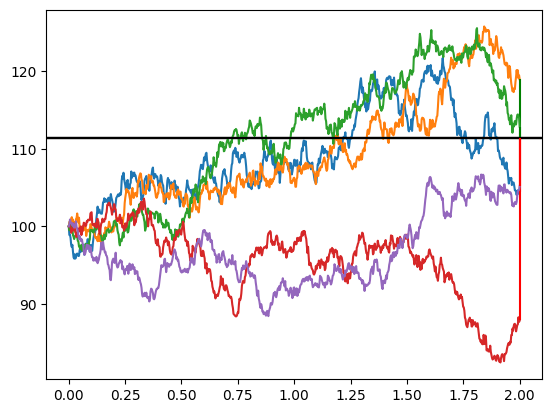

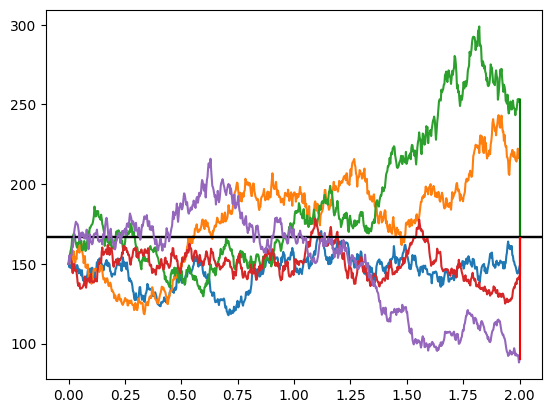

In [5]:
opt1_premium = np.exp(-r*T) * np.mean(np.maximum(S1[-1,:] - 100, 0))
opt2_premium = np.exp(-r*T) * np.mean(np.maximum(S2[-1,:] - 150, 0))
capital1 = (n * S1_0) + (alpha1 * n * opt1_premium)
capital2 = (n * S2_0) + (alpha2 * n * opt2_premium)
for x in range(5):

    plt.axhline(option1,color="black")
    plt.plot(t,S1[:,x])
    plt.vlines(t[-1],option1,S1[-1,x],color=("red" if option1>S1[-1,x] else "green"))
plt.show()

for x in range(5):
    plt.axhline(option2,color="black")
    plt.plot(t,S2[:,x])
    plt.vlines(t[-1],option2,S2[-1,x],color=("red" if option2>S2[-1,x] else "green"))
plt.show()

In [6]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(3,32),
            nn.Tanh(),
            nn.Linear(32,64),
            nn.Tanh(),
            nn.Linear(64,16),
            nn.Tanh(),
            nn.Linear(16,1)
        )
    
    def forward(self,t,y1,y2):
        x = torch.stack([t, y1, y2], dim=0).unsqueeze(0)
        return self.net(x)
    
    def set(self, t, y1, y2):
        # 1. Ensure inputs track gradients (crucial for physics/differential equations)
        t = torch.tensor(t, dtype=torch.float32, requires_grad=True)
        y1 = torch.tensor(y1, dtype=torch.float32, requires_grad=True)
        y2 = torch.tensor(y2, dtype=torch.float32, requires_grad=True)
        # 2. Forward passes (returning 1 scalar each)
        w1 = self.forward(t, y1, y2)
        w2 = self.forward(t, y2, y1)
        #print(w1,w2)


        # 3. Take gradients of the scalar output w1 with respect to y1 and y2
        dw1 = torch.autograd.grad(w1, y1, grad_outputs=torch.ones_like(w1), create_graph=True,allow_unused=True)[0]
        dw2 = torch.autograd.grad(w1, y2, grad_outputs=torch.ones_like(w1), create_graph=True,allow_unused=True)[0]
        
        # 4. Compute the scalar multiplier factor
        scalar_factor = 1.0 / (dw1**2 - dw2**2)
        
        # 5. Build the 2x2 matrix row-by-row using torch.stack
        row1 = torch.stack([dw1, -dw2])
        row2 = torch.stack([-dw2, dw1])
        matrix = torch.stack([row1, row2])
        
        # 6. Apply the scalar multiplier to the matrix
        A = scalar_factor * matrix
        
        return w1, w2, A
        

In [7]:
model=PINN()
model.load_state_dict(torch.load('model.pth', weights_only=True,map_location=torch.device('cpu')))
model.eval()

PINN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [8]:
def compare_strats(toggle):
    t,S1=simulate_gbm(100,np.random.rand()*0.05,np.random.rand()*0.3,2,750,1000)
    option1,weight1=black_scholes(100,100)
    option1=option1+100

    t,S2=simulate_gbm(150,np.random.rand()*0.1-0.05,np.random.rand()*0.3,2,750,1000)
    option2,weight2=black_scholes(150,150)
    option2=option2+150

    n = 100 

    # 1. Single-share prices today
    S1_0 = 100.0
    S2_0 = 150.0

    r=0.05
    sigma=0.3
    T=2
    K=100
    K1=0.5
    K2=1-K1

    percentage_margin=1
    # 2. Get single-share simulated option prices (No 'n' multiplication here)


    # 3. Define your Alpha hedge factors (1/weight)
    alpha1 = 1 / weight1
    alpha2 = 1 / weight2

    # 1. Single-share prices today
    S1_0 = 100.0
    S2_0 = 150.0

    # 2. Get single-share simulated option prices (No 'n' multiplication here)
    opt1_premium = np.exp(-r*T) * np.mean(np.maximum(S1[-1,:] - 100, 0))
    opt2_premium = np.exp(-r*T) * np.mean(np.maximum(S2[-1,:] - 150, 0))

    # 3. Define your Alpha hedge factors (1/weight)
    alpha1 = 1 / weight1
    alpha2 = 1 / weight2

    # 4. Calculate Total Capital Invested Today (Denominator)
    if(option1>opt1_premium):
        capital1=alpha1*opt1_premium+percentage_margin*S1_0
        payoff1=alpha1*np.mean(np.maximum(S1[-1,:]-100,0))+S1_0-np.mean(S1[-1,:])+percentage_margin*S1_0
    else:
        capital1=alpha1*(S1_0-opt1_premium)+S1_0
        payoff1=-1*alpha1*np.mean(np.maximum(S1[-1,:]-100,0))+np.mean(S1[-1,:])*(alpha1+1)

    if(option2>opt2_premium):
        capital2=alpha2*opt2_premium+percentage_margin*S2_0
        payoff2=alpha2*np.mean(np.maximum(S2[-1,:]-150,0))+S2_0-np.mean(S2[-1,:])+percentage_margin*S2_0
    else:
        capital2=alpha2*(S2_0-opt2_premium)+S2_0
        payoff2=-1*alpha2*np.mean(np.maximum(S2[-1,:]-150,0))+np.mean(S2[-1,:])*(alpha2+1)

    # 6. Clean Percentage Returns per Asset
    profit1 = (payoff1 - capital1) / capital1
    profit2 = (payoff2 - capital2) / capital2

    # 7. Combined Portfolio Return (Weighted by your portfolio allocations K1 and K2)
    # Ensure K1 + K2 = 1.0 if they are portfolio weights!
    total_return_percentage = (K1 * profit1 + K2 * profit2) * 100


    y1=100
    y2=150

    with torch.enable_grad():
        price1,price2,W=model.set(T,y1,y2)

    n=100
    price1=price1.detach().numpy()[0][0]
    price2=price2.detach().numpy()[0][0]
    W=W.detach().numpy()

    K=(np.array([K1,K2]).T)
    Y=(np.array([100,150]).T)



    Capital=np.array([[0],[0]])
    Payoff=np.array([[0],[0]])

    Alpha=np.reshape((K.T@W),(2,1))

    if(opt1_premium>price1):
        Capital[0][0]=Alpha[0][0]*(y1-opt1_premium)+K1*y1
        Payoff[0][0]=(Alpha[0][0]+K1)*np.mean(S1[-1,:])-Alpha[0][0]*np.mean(np.maximum(S1[-1,:],100))
    else:
        Capital[0][0]=Alpha[0][0]*opt1_premium+percentage_margin*K1*y1
        Payoff[0][0]=K1*(y1-np.mean(S1[-1,:]))+percentage_margin*K1*y1+Alpha[0][0]*np.mean(np.maximum(S1[-1,:]-100,0))

    if(opt2_premium>price2):
        Capital[1][0]=Alpha[1][0]*(y2-opt2_premium)+K2*y2
        Payoff[1][0]=(Alpha[1][0]+K2)*np.mean(S2[-1,:])-Alpha[1][0]*np.mean(np.maximum(S2[-1,:],150))
    else:
        Capital[1][0]=Alpha[1][0]*opt2_premium+percentage_margin*K2*y2
        Payoff[1][0]=K2*(y2-np.mean(S2[-1,:]))+percentage_margin*K2*y2+Alpha[1][0]*np.mean(np.maximum(S2[-1,:]-150,0))

    f=np.ones_like(Payoff)
    Profit=(((f.T@(Payoff-Capital))/(f.T@Capital))*100)[0][0]
    if toggle==0:
        print(f"Returns in my strategy  are: {Profit:.2f}%")
        print(f"Returns in strategy other are: {total_return_percentage:.2f}%")
    return Profit,total_return_percentage

In [9]:
Trials=10000
My_strat=[]
Original_Strat=[]
for x in range(Trials):
    x,y=compare_strats(x%1000)
    My_strat.append(x)
    Original_Strat.append(y)

Returns in my strategy  are: -4.90%
Returns in strategy other are: -67.05%
Returns in my strategy  are: 0.00%
Returns in strategy other are: -1.42%
Returns in my strategy  are: 3.82%
Returns in strategy other are: -9.06%
Returns in my strategy  are: -1.57%
Returns in strategy other are: -3.47%
Returns in my strategy  are: -34.57%
Returns in strategy other are: -44.04%
Returns in my strategy  are: 1.46%
Returns in strategy other are: -17.67%
Returns in my strategy  are: -4.35%
Returns in strategy other are: -22.98%
Returns in my strategy  are: 2.19%
Returns in strategy other are: -27.44%
Returns in my strategy  are: 0.00%
Returns in strategy other are: -3.81%
Returns in my strategy  are: -34.24%
Returns in strategy other are: -133.49%


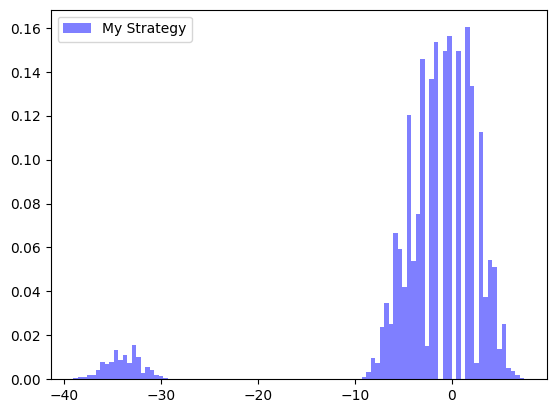

In [10]:
My_strat=np.array(My_strat)
Original_Strat=np.array(Original_Strat)
plt.hist(My_strat,density=True,bins=100,color="blue",alpha=0.5,label="My Strategy")
plt.legend()
plt.show()

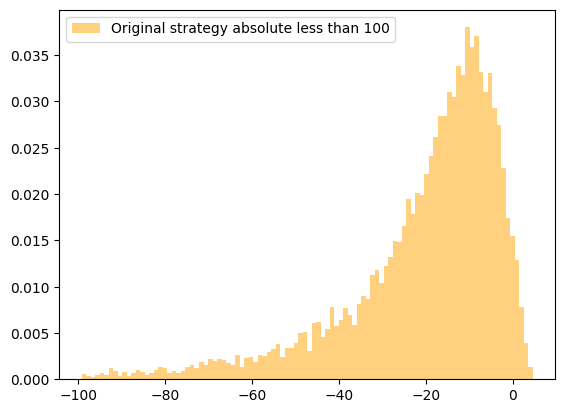

In [11]:
plt.hist(Original_Strat[np.abs(Original_Strat)<100],density=True,bins=100,color="orange",alpha=0.5,label="Original strategy absolute less than 100")
plt.legend()
plt.show()

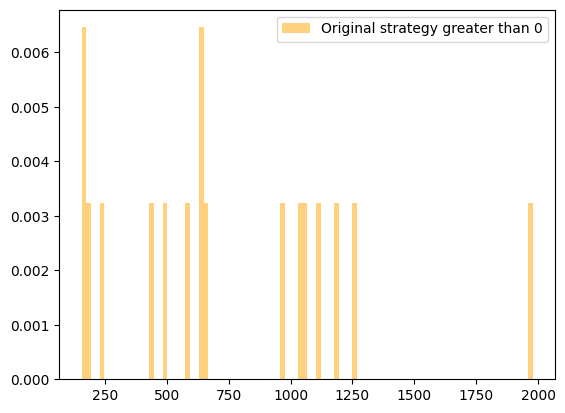

In [12]:
plt.hist(Original_Strat[(Original_Strat)>10],density=True,bins=100,color="orange",alpha=0.5,label="Original strategy greater than 0")
plt.legend()
plt.show()

/tmp/ipykernel_10960/4220206241.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


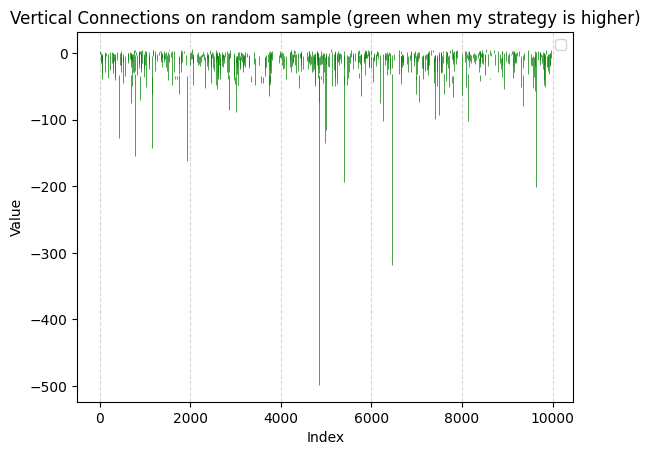

In [13]:
X=np.arange(len(My_strat))
sample = np.random.choice(X, size=500, replace=False)
colors = np.where(My_strat[sample] >= Original_Strat[sample], "green", "red")
plt.vlines(sample, ymin=Original_Strat[sample], ymax=My_strat[sample], colors=colors, linewidth=0.5, zorder=2)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Vertical Connections on random sample (green when my strategy is higher)")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

/tmp/ipykernel_10960/991829927.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


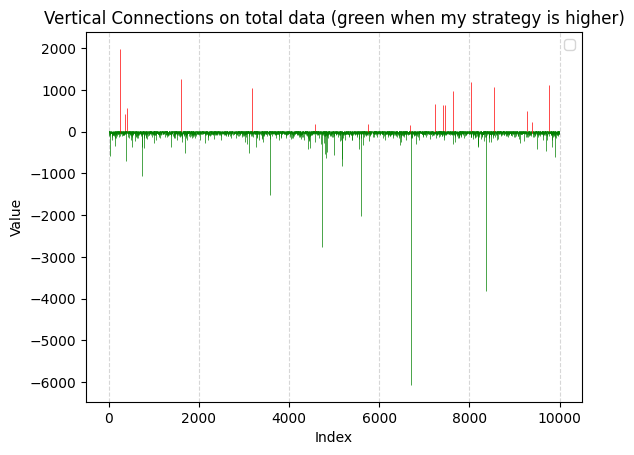

In [14]:
X=np.arange(len(My_strat))
sample = X
colors = np.where(My_strat[sample] >= Original_Strat[sample], "green", "red")
plt.vlines(sample, ymin=Original_Strat[sample], ymax=My_strat[sample], colors=colors, linewidth=0.5, zorder=2)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Vertical Connections on total data (green when my strategy is higher)")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()